# Synthetic Test Response Generation with Correlated Item Facilities

This notebook demonstrates how to generate synthetic correct/incorrect responses for test items where:
1. Each participant has item-specific success probabilities (item facilities)
2. Item facilities follow Beta distributions
3. Participants' facilities for the same item are correlated using a Gaussian copula

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import norm, beta
import pandas as pd

from alignsim.distributions import (
    get_beta_dist_from_variance,
    get_beta_dist_from_evidence
)
from alignsim.calculate import (
    calculate_3d_agreement,
    calculate_empirical_accuracy,
    calculate_geirhos_error_matrix,
    calculate_geirhos_metrics,
    calculate_geirhos_from_validations
)

from alignsim.simulate import (
    generate_correlated_beta_distributed_samples,
    generate_validations
)


# Set style
# plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
%matplotlib inline

## Core Functions

### The Gaussian Copula Approach

The Gaussian copula allows us to:
1. Generate correlated normal random variables
2. Transform to uniform [0,1] using the normal CDF
3. Transform to any target distribution (Beta) using inverse CDF

This preserves the correlation structure while allowing different marginal distributions.

In [ ]:
# def generate_correlated_beta_distributed_samples(n_items, alpha1, beta1, alpha2, beta2, correlation):
#     """
#     Generate correlated Beta-distributed samples using a Gaussian copula.
    
#     Parameters:
#     -----------
#     n_items : int
#         Number of items (test questions)
#     alpha1, beta1 : float
#         Beta distribution shape parameters for participant 1
#     alpha2, beta2 : float
#         Beta distribution shape parameters for participant 2
#     correlation : float
#         Desired correlation coefficient between participants' item facilities (-1 to 1)
    
#     Returns:
#     --------
#     facilities1, facilities2 : np.ndarray
#         Arrays of shape (n_items,) containing item facilities for each participant
#     """
#     # Step 1: Generate correlated bivariate normal samples
#     mean = [0, 0]
#     cov = [[1, correlation],
#            [correlation, 1]]
    
#     normal_samples = np.random.multivariate_normal(mean, cov, size=n_items)
    
#     # Step 2: Transform to uniform using normal CDF
#     uniform_samples = norm.cdf(normal_samples)
    
#     # Step 3: Transform to Beta using inverse CDF (quantile function)
#     facilities1 = beta.ppf(uniform_samples[:, 0], alpha1, beta1)
#     facilities2 = beta.ppf(uniform_samples[:, 1], alpha2, beta2)
    
#     return facilities1, facilities2


# def generate_validations(item_facilities):
#     """
#     Generate binary correct/incorrect responses based on item facilities.
#     """
#     return (np.random.uniform(size=len(item_facilities)) < item_facilities).astype(int)

## Example 1: Basic Usage

Generate data for 100 items with moderate correlation.

In [2]:
# Set random seed for reproducibility
np.random.seed(42)

# Parameters
n_items = 1280
evidence = 1
mean_acc1 = 0.9
dist1 = get_beta_dist_from_evidence(mean_acc1, evidence)
alpha1, beta1 = dist1.args

mean_acc2 = 0.95
dist2 = get_beta_dist_from_evidence(mean_acc2, evidence)

alpha2, beta2 = dist2.args
correlation = 1

# Generate correlated facilities
fac1, fac2 = generate_correlated_beta_distributed_samples(n_items, alpha1, beta1, alpha2, beta2, correlation)

# Generate responses
resp1 = generate_validations(fac1)
resp2 = generate_validations(fac2)

# Create DataFrame
df = pd.DataFrame({
    'item_id': range(n_items),
    'facility_p1': fac1,
    'facility_p2': fac2,
    'response_p1': resp1,
    'response_p2': resp2
})

print("First 10 items:")
print(df.head(10))
print(f"\nActual correlation: {np.corrcoef(fac1, fac2)[0,1]:.3f}")
print(f"Participant 1 accuracy: {resp1.mean():.3f}")
print(f"Participant 2 accuracy: {resp2.mean():.3f}")

First 10 items:
   item_id  facility_p1  facility_p2  response_p1  response_p2
0        0     0.971098     0.999345            1            1
1        1     0.941132     0.997266            1            1
2        2     0.999851     1.000000            1            1
3        3     0.389217     0.671039            1            1
4        4     0.999987     1.000000            1            1
5        5     0.999986     1.000000            1            1
6        6     0.993379     0.999966            1            1
7        7     1.000000     1.000000            1            1
8        8     1.000000     1.000000            1            1
9        9     1.000000     1.000000            1            1

Actual correlation: 0.943
Participant 1 accuracy: 0.908
Participant 2 accuracy: 0.952


In [3]:
mtx = calculate_geirhos_from_validations(resp1, resp2)
metrics = calculate_geirhos_metrics(mtx)
print(f"Corresponding EC: {metrics['kappa']} ")

Corresponding EC: 0.44236402061473407 


## Visualization: Verify the Copula Works

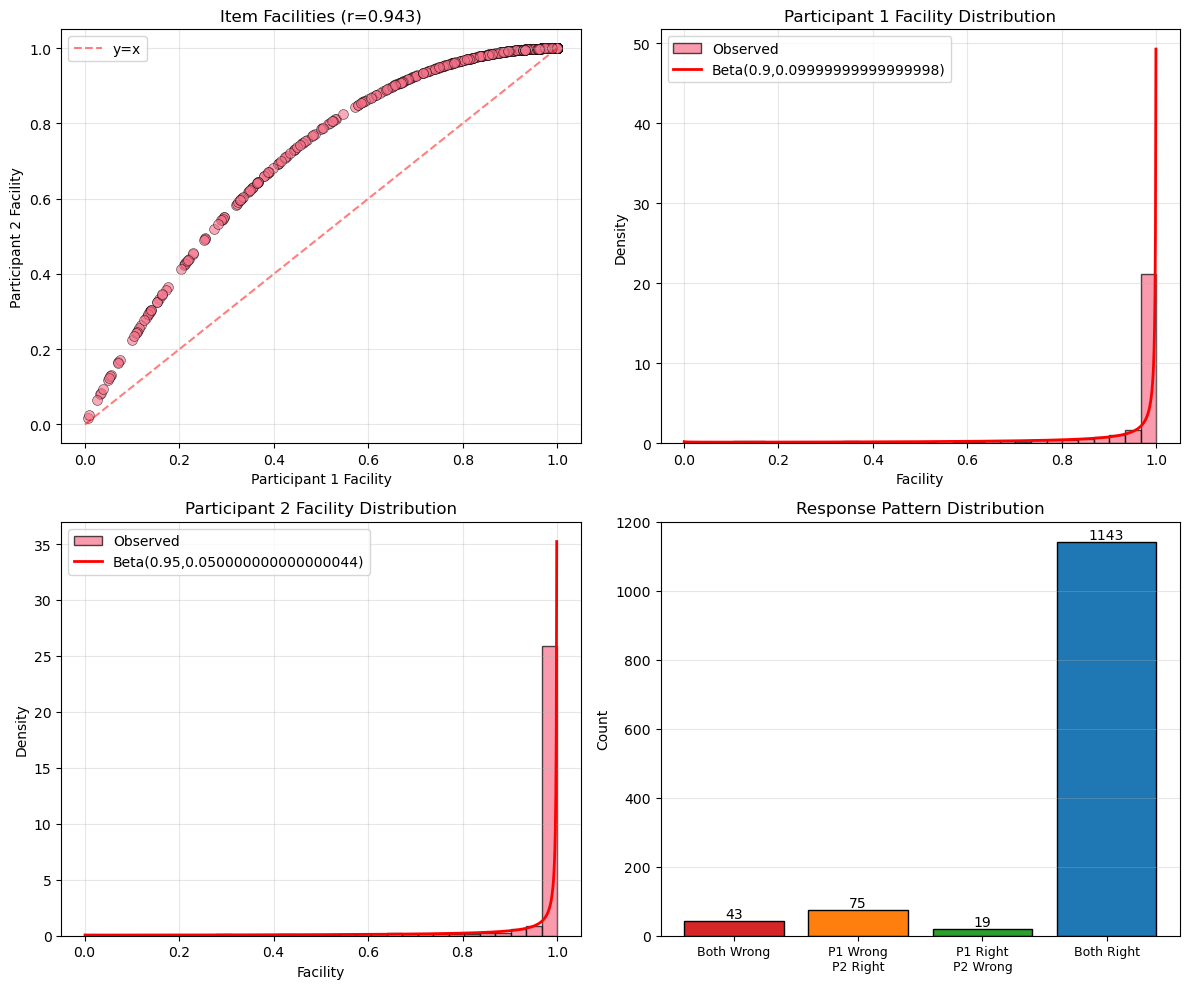

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. Scatter plot of facilities
ax = axes[0, 0]
ax.scatter(fac1, fac2, alpha=0.6, s=50, edgecolors='black', linewidths=0.5)
ax.plot([0, 1], [0, 1], 'r--', alpha=0.5, label='y=x')
ax.set_xlabel('Participant 1 Facility')
ax.set_ylabel('Participant 2 Facility')
ax.set_title(f'Item Facilities (r={np.corrcoef(fac1, fac2)[0,1]:.3f})')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. Distribution of facilities - P1
ax = axes[0, 1]
ax.hist(fac1, bins=30, density=True, alpha=0.7, edgecolor='black', label='Observed')
x = np.linspace(0, 1, 1000)
ax.plot(x, beta.pdf(x, alpha1, beta1), 'r-', linewidth=2, label=f'Beta({alpha1},{beta1})')
ax.set_xlabel('Facility')
ax.set_ylabel('Density')
ax.set_title('Participant 1 Facility Distribution')
ax.legend()
ax.grid(True, alpha=0.3)

# 3. Distribution of facilities - P2
ax = axes[1, 0]
ax.hist(fac2, bins=30, density=True, alpha=0.7, edgecolor='black', label='Observed')
ax.plot(x, beta.pdf(x, alpha2, beta2), 'r-', linewidth=2, label=f'Beta({alpha2},{beta2})')
ax.set_xlabel('Facility')
ax.set_ylabel('Density')
ax.set_title('Participant 2 Facility Distribution')
ax.legend()
ax.grid(True, alpha=0.3)

# 4. Response agreement
ax = axes[1, 1]
response_combos = df.groupby(['response_p1', 'response_p2']).size()
labels = ['Both Wrong', 'P1 Wrong\nP2 Right', 'P1 Right\nP2 Wrong', 'Both Right']
counts = [response_combos.get((0,0), 0), response_combos.get((0,1), 0),
          response_combos.get((1,0), 0), response_combos.get((1,1), 0)]
colors = ['#d62728', '#ff7f0e', '#2ca02c', '#1f77b4']
bars = ax.bar(range(4), counts, color=colors, edgecolor='black')
ax.set_xticks(range(4))
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel('Count')
ax.set_title('Response Pattern Distribution')
ax.grid(True, alpha=0.3, axis='y')

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height, f'{int(height)}',
            ha='center', va='bottom')

plt.tight_layout()
plt.show()

## Example 2: Different Beta Distributions for Each Participant

Model different ability levels by using different Beta parameters.

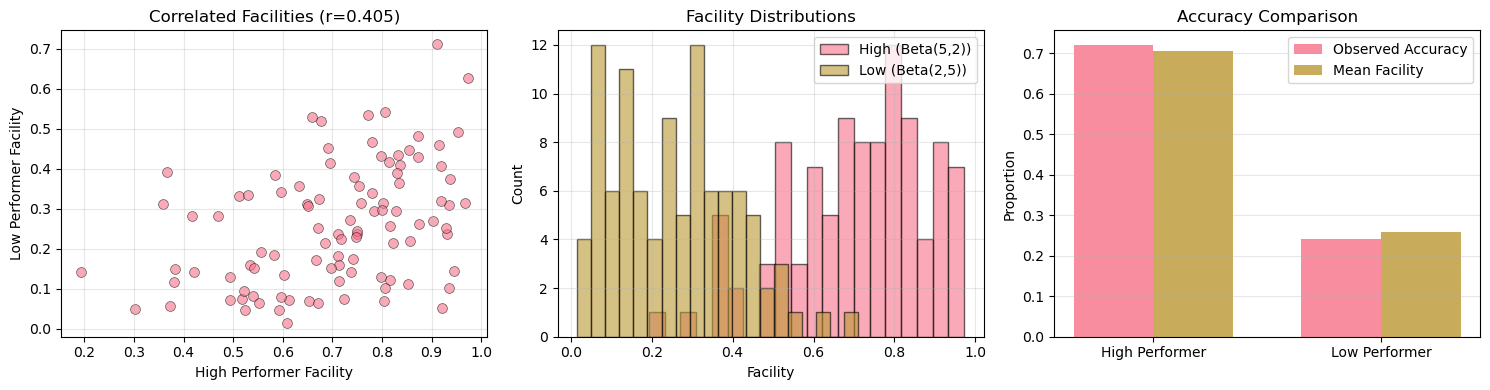

High performer accuracy: 0.720
Low performer accuracy: 0.240


In [5]:
np.random.seed(123)

# High-performing participant (Beta(5,2) - skewed right)
# Low-performing participant (Beta(2,5) - skewed left)
fac_high, fac_low = generate_correlated_beta_distributed_samples(
    n_items=100,
    alpha1=5, beta1=2,  # High performer
    alpha2=2, beta2=5,  # Low performer
    correlation=0.5
)

resp_high = generate_validations(fac_high)
resp_low = generate_validations(fac_low)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Scatter
axes[0].scatter(fac_high, fac_low, alpha=0.6, s=50, edgecolors='black', linewidths=0.5)
axes[0].set_xlabel('High Performer Facility')
axes[0].set_ylabel('Low Performer Facility')
axes[0].set_title(f'Correlated Facilities (r={np.corrcoef(fac_high, fac_low)[0,1]:.3f})')
axes[0].grid(True, alpha=0.3)

# Distributions
axes[1].hist(fac_high, bins=20, alpha=0.6, label='High (Beta(5,2))', edgecolor='black')
axes[1].hist(fac_low, bins=20, alpha=0.6, label='Low (Beta(2,5))', edgecolor='black')
axes[1].set_xlabel('Facility')
axes[1].set_ylabel('Count')
axes[1].set_title('Facility Distributions')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Accuracies
acc_data = pd.DataFrame({
    'Participant': ['High Performer', 'Low Performer'],
    'Accuracy': [resp_high.mean(), resp_low.mean()],
    'Mean Facility': [fac_high.mean(), fac_low.mean()]
})

x = np.arange(2)
width = 0.35
axes[2].bar(x - width/2, acc_data['Accuracy'], width, label='Observed Accuracy', alpha=0.8)
axes[2].bar(x + width/2, acc_data['Mean Facility'], width, label='Mean Facility', alpha=0.8)
axes[2].set_ylabel('Proportion')
axes[2].set_title('Accuracy Comparison')
axes[2].set_xticks(x)
axes[2].set_xticklabels(acc_data['Participant'])
axes[2].legend()
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"High performer accuracy: {resp_high.mean():.3f}")
print(f"Low performer accuracy: {resp_low.mean():.3f}")

## Example 3: Effect of Correlation Strength

Compare different correlation levels.

In [ ]:
np.random.seed(789)

correlations = [0.0, 0.3, 0.6, 0.9]
n_items = 200

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, corr in enumerate(correlations):
    fac1, fac2 = generate_correlated_beta_distributed_samples(
        n_items, alpha1=2, beta1=2, alpha2=2, beta2=2, correlation=corr
    )
    
    actual_corr = np.corrcoef(fac1, fac2)[0, 1]
    
    axes[i].scatter(fac1, fac2, alpha=0.5, s=30, edgecolors='black', linewidths=0.3)
    axes[i].plot([0, 1], [0, 1], 'r--', alpha=0.5)
    axes[i].set_xlabel('Participant 1 Facility')
    axes[i].set_ylabel('Participant 2 Facility')
    axes[i].set_title(f'Target r={corr:.1f}, Actual r={actual_corr:.3f}')
    axes[i].grid(True, alpha=0.3)
    axes[i].set_xlim([0, 1])
    axes[i].set_ylim([0, 1])

plt.tight_layout()
plt.show()

## Example 4: Multi-Participant Extension

Extend to more than 2 participants.

In [ ]:
def generate_multi_participant_data(n_items, n_participants, beta_params, correlation_matrix, seed=None):
    """
    Generate data for multiple participants with specified correlation structure.
    
    Parameters:
    -----------
    n_items : int
        Number of test items
    n_participants : int
        Number of participants
    beta_params : list of tuples
        List of (alpha, beta) parameters for each participant
    correlation_matrix : np.ndarray
        n_participants x n_participants correlation matrix
    seed : int, optional
        Random seed
    
    Returns:
    --------
    facilities : np.ndarray
        Array of shape (n_items, n_participants)
    responses : np.ndarray
        Array of shape (n_items, n_participants)
    """
    if seed is not None:
        np.random.seed(seed)
    
    # Generate correlated normal samples
    mean = np.zeros(n_participants)
    normal_samples = np.random.multivariate_normal(mean, correlation_matrix, size=n_items)
    
    # Transform to uniform
    uniform_samples = norm.cdf(normal_samples)
    
    # Transform to Beta for each participant
    facilities = np.zeros((n_items, n_participants))
    for i in range(n_participants):
        alpha, beta_param = beta_params[i]
        facilities[:, i] = beta.ppf(uniform_samples[:, i], alpha, beta_param)
    
    # Generate responses
    responses = (np.random.uniform(size=(n_items, n_participants)) < facilities).astype(int)
    
    return facilities, responses


# Example: 4 participants with different abilities
n_participants = 4
beta_params = [(5, 2), (4, 3), (3, 4), (2, 5)]  # Decreasing ability

# Correlation matrix (moderate positive correlations)
corr_matrix = np.array([
    [1.0, 0.6, 0.5, 0.4],
    [0.6, 1.0, 0.6, 0.5],
    [0.5, 0.6, 1.0, 0.6],
    [0.4, 0.5, 0.6, 1.0]
])

facilities, responses = generate_multi_participant_data(
    n_items=100,
    n_participants=4,
    beta_params=beta_params,
    correlation_matrix=corr_matrix,
    seed=999
)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Correlation heatmap
actual_corr = np.corrcoef(facilities.T)
im = axes[0].imshow(actual_corr, cmap='coolwarm', vmin=-1, vmax=1)
axes[0].set_xticks(range(4))
axes[0].set_yticks(range(4))
axes[0].set_xticklabels([f'P{i+1}' for i in range(4)])
axes[0].set_yticklabels([f'P{i+1}' for i in range(4)])
axes[0].set_title('Actual Facility Correlations')
plt.colorbar(im, ax=axes[0])

# Add correlation values
for i in range(4):
    for j in range(4):
        text = axes[0].text(j, i, f'{actual_corr[i, j]:.2f}',
                           ha="center", va="center", color="black", fontsize=10)

# Accuracy comparison
accuracies = responses.mean(axis=0)
mean_facilities = facilities.mean(axis=0)

x = np.arange(4)
width = 0.35
axes[1].bar(x - width/2, accuracies, width, label='Observed Accuracy', alpha=0.8)
axes[1].bar(x + width/2, mean_facilities, width, label='Mean Facility', alpha=0.8)
axes[1].set_xlabel('Participant')
axes[1].set_ylabel('Proportion')
axes[1].set_title('Accuracy by Participant')
axes[1].set_xticks(x)
axes[1].set_xticklabels([f'P{i+1}' for i in range(4)])
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("Participant accuracies:")
for i in range(4):
    print(f"  P{i+1}: {accuracies[i]:.3f} (mean facility: {mean_facilities[i]:.3f})")

## Example 5: Understanding Beta Distribution Parameters

Visualize how different Beta parameters affect the facility distributions.

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

beta_params_list = [
    (2, 2, "Symmetric (α=2, β=2)"),
    (5, 5, "Symmetric peaked (α=5, β=5)"),
    (0.5, 0.5, "U-shaped (α=0.5, β=0.5)"),
    (5, 2, "Right-skewed (α=5, β=2)"),
    (2, 5, "Left-skewed (α=2, β=5)"),
    (1, 1, "Uniform (α=1, β=1)")
]

x = np.linspace(0.001, 0.999, 1000)

for i, (alpha, beta_param, title) in enumerate(beta_params_list):
    # Sample from distribution
    samples = np.random.beta(alpha, beta_param, 1000)
    
    # Plot
    axes[i].hist(samples, bins=30, density=True, alpha=0.6, edgecolor='black')
    axes[i].plot(x, beta.pdf(x, alpha, beta_param), 'r-', linewidth=2)
    axes[i].set_title(title)
    axes[i].set_xlabel('Facility')
    axes[i].set_ylabel('Density')
    axes[i].grid(True, alpha=0.3)
    axes[i].set_xlim([0, 1])
    
    # Add mean line
    mean = alpha / (alpha + beta_param)
    axes[i].axvline(mean, color='green', linestyle='--', linewidth=1.5, label=f'Mean={mean:.2f}')
    axes[i].legend(fontsize=8)

plt.tight_layout()
plt.show()

## Save Data for Further Analysis

In [ ]:
# Generate a final dataset
np.random.seed(42)

final_fac1, final_fac2 = generate_correlated_beta_distributed_samples(
    n_items=200,
    alpha1=3, beta1=2,
    alpha2=2, beta2=3,
    correlation=0.7
)

final_resp1 = generate_validations(final_fac1)
final_resp2 = generate_validations(final_fac2)

final_df = pd.DataFrame({
    'item_id': range(200),
    'participant_1_facility': final_fac1,
    'participant_2_facility': final_fac2,
    'participant_1_response': final_resp1,
    'participant_2_response': final_resp2
})

final_df.to_csv('synthetic_test_data.csv', index=False)
print("Data saved to 'synthetic_test_data.csv'")
print(f"\nDataset summary:")
print(f"  Items: {len(final_df)}")
print(f"  Correlation: {np.corrcoef(final_fac1, final_fac2)[0,1]:.3f}")
print(f"  P1 accuracy: {final_resp1.mean():.3f}")
print(f"  P2 accuracy: {final_resp2.mean():.3f}")